# 02 Experiments


## Section 2.1 - Setup


In [1]:
import logging

import lakefs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

from helpers import (
    compute_binary_classification_metrics,
    create_branch,
    create_xgboost_classifier,
    engineer_time_features,
    engineer_route_features,
    frequency_encode,
    compute_delay_rates,
    apply_delay_rates,
    get_branch_log,
    lakefs_commit,
    load_metrics_from_lakefs,
    load_metrics_json,
    load_predictions_from_lakefs,
    load_predictions_parquet,
    merge_branch,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_pr_curve_overlay,
    plot_precision_recall_curve,
    read_parquet,
    save_metrics_json,
    save_predictions_parquet,
    temporal_train_test_split,
    write_parquet,
)
from notebook_setup import build_notebook_config, initialize_lakefs_repository

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
LOGGER = logging.getLogger("02_experiments")


In [2]:
config = build_notebook_config()
init_result = initialize_lakefs_repository(config)
print(init_result.message)

lakefs_client = lakefs.Client(
    host=config.endpoint,
    username=config.access_key,
    password=config.secret_key,
)

LOGGER.info("Loading silver dataset from branch-aware path")
silver_repo = lakefs.Repository(config.repo_name, client=lakefs_client)
silver_obj = silver_repo.branch("silver").object("silver/flights_2023_clean.parquet")
with silver_obj.reader(mode="rb") as reader:
    silver_df = pd.read_parquet(reader)

print("silver shape:", silver_df.shape)
display(silver_df.head())


INFO 02_experiments: Loading silver dataset from branch-aware path


Connected to lakeFS repository 'flight-delay-demo' at http://lakefs.scilake.svc:8080. default_branch_exists=True.
silver shape: (454413, 35)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,year,is_delayed_pre,is_delayed
0,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,249.0,1589.0,0.0,0.0,24.0,0.0,0.0,2023,1,1
1,2023-06-11,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2134,DCA,"Washington, DC",BOS,"Boston, MA",...,58.0,399.0,NaN,NaN,NaN,NaN,NaN,2023,0,0
2,2023-02-12,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,590,IAH,"Houston, TX",LAX,"Los Angeles, CA",...,200.0,1379.0,NaN,NaN,NaN,NaN,NaN,2023,0,0
3,2023-04-15,Republic Airline,Republic Airline: YX,YX,20452,3615,MSP,"Minneapolis, MN",EWR,"Newark, NJ",...,145.0,1008.0,0.0,0.0,1124.0,0.0,0.0,2023,1,1
4,2023-01-03,Allegiant Air,Allegiant Air: G4,G4,20368,1206,USA,"Concord, NC",SFB,"Sanford, FL",...,70.0,457.0,NaN,NaN,NaN,NaN,NaN,2023,0,0


## Section 2.2 - Experiment A: Time-Based Features

Engineer time-based features (hour, day-of-week, month, weekend, holiday, time bucket),
label-encode categoricals, train XGBoost, and persist gold artifacts to lakeFS.


In [3]:
# --- 2.2a: Create experiment branch and engineer time features ---
BRANCH_TIME = "experiment-time-features"
create_branch(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_TIME,
    source_branch="silver",
)
print(f"Branch '{BRANCH_TIME}' ready (from silver)")

# Engineer time features from silver dataset
time_df = engineer_time_features(silver_df)
print("Time features engineered, shape:", time_df.shape)
display(time_df[["FL_DATE", "DEP_TIME", "hour_of_day", "day_of_week", "month",
                  "is_weekend", "is_holiday_period", "time_of_day_bucket"]].head(10))


Branch 'experiment-time-features' ready (from silver)
Time features engineered, shape: (454413, 41)


,FL_DATE,DEP_TIME,hour_of_day,day_of_week,month,is_weekend,is_holiday_period,time_of_day_bucket
0,2023-03-06,1608.0,16,0,3,0,0,afternoon
1,2023-06-11,1001.0,10,6,6,1,0,morning
2,2023-02-12,527.0,5,6,2,1,0,early_morning
3,2023-04-15,714.0,7,5,4,1,0,early_morning
4,2023-01-03,1531.0,15,1,1,0,1,afternoon
5,2023-07-23,521.0,5,6,7,1,1,early_morning
6,2023-07-03,1350.0,13,0,7,0,1,afternoon
7,2023-04-08,2133.0,21,5,4,1,0,evening
8,2023-01-16,1725.0,17,0,1,0,0,afternoon
9,2023-04-06,1007.0,10,3,4,0,0,morning


In [4]:
# --- 2.2b: Label-encode categoricals and build feature matrix ---

# Label-encode categorical columns for Experiment A
le_airline = LabelEncoder()
le_origin = LabelEncoder()
le_bucket = LabelEncoder()

time_df["airline_enc"] = le_airline.fit_transform(time_df["AIRLINE_CODE"].astype(str))
time_df["origin_enc"] = le_origin.fit_transform(time_df["ORIGIN"].astype(str))
time_df["bucket_enc"] = le_bucket.fit_transform(time_df["time_of_day_bucket"].astype(str))

# Define feature columns for Experiment A
TIME_FEATURE_COLS = [
    "hour_of_day",
    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday_period",
    "bucket_enc",
    "airline_enc",
    "origin_enc",
    "DISTANCE",
]
TARGET_COL = "is_delayed"

features_time = time_df[TIME_FEATURE_COLS + [TARGET_COL, "FL_DATE"]].copy()
print("Feature matrix shape:", features_time.shape)
print("Feature columns:", TIME_FEATURE_COLS)
print("Class balance:")
print(features_time[TARGET_COL].value_counts(normalize=True))


Feature matrix shape: (454413, 11)
Feature columns: ['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_holiday_period', 'bucket_enc', 'airline_enc', 'origin_enc', 'DISTANCE']
Class balance:
is_delayed
0    0.777088
1    0.222912
Name: proportion, dtype: float64


In [5]:
# --- 2.2c: Temporal split and persist gold feature artifact ---
CUTOFF_DATE = "2023-07-01"
X_train_t, X_test_t, y_train_t, y_test_t = temporal_train_test_split(
    features_time, target_col=TARGET_COL, date_col="FL_DATE", cutoff_date=CUTOFF_DATE
)
print(f"Temporal split (cutoff={CUTOFF_DATE}): Train: {X_train_t.shape}, Test: {X_test_t.shape}")
print(f"Train delay rate: {y_train_t.mean():.4f}, Test delay rate: {y_test_t.mean():.4f}")

# Write gold feature artifact to lakeFS
write_parquet(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_TIME,
    path="gold/features_time.parquet",
    df=features_time,
)
lakefs_commit(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_TIME,
    message="Gold layer: time-based features",
    metadata={"phase": "phase-5", "layer": "gold", "experiment": "time"},
)
print("gold/features_time.parquet committed on", BRANCH_TIME)


Temporal split (cutoff=2023-07-01): Train: (334493, 9), Test: (119920, 9)
Train delay rate: 0.2149, Test delay rate: 0.2453
gold/features_time.parquet committed on experiment-time-features


In [6]:
# --- 2.2d: Train XGBoost model ---
model_time = create_xgboost_classifier(random_state=42)
model_time.fit(X_train_t, y_train_t)
print("XGBoost (time) training complete")

# Predict
y_pred_t = model_time.predict(X_test_t)
y_scores_t = model_time.predict_proba(X_test_t)[:, 1]

# Compute metrics
metrics_time = compute_binary_classification_metrics(y_test_t, y_pred_t, y_scores_t)
print("\n=== Experiment A (Time Features) Metrics ===")
for k, v in metrics_time.items():
    print(f"  {k}: {v:.4f}")


XGBoost (time) training complete

=== Experiment A (Time Features) Metrics ===
  accuracy: 0.7700
  precision: 0.5636
  recall: 0.2762
  f1: 0.3708
  auc_pr: 0.4949


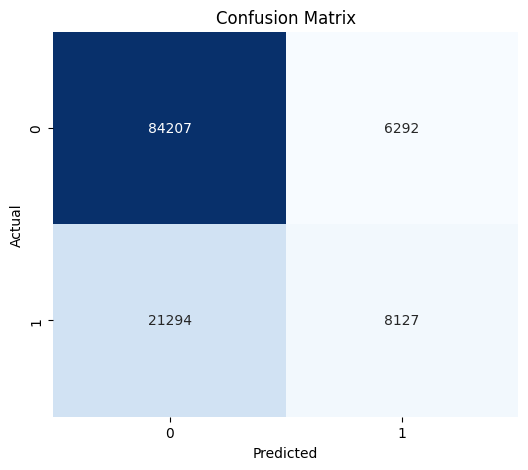

Saved: outputs/charts/confusion_matrix_time.png


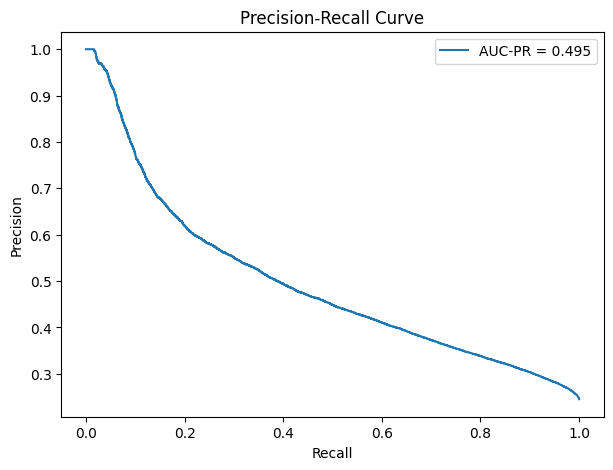

Saved: outputs/charts/pr_curve_time.png


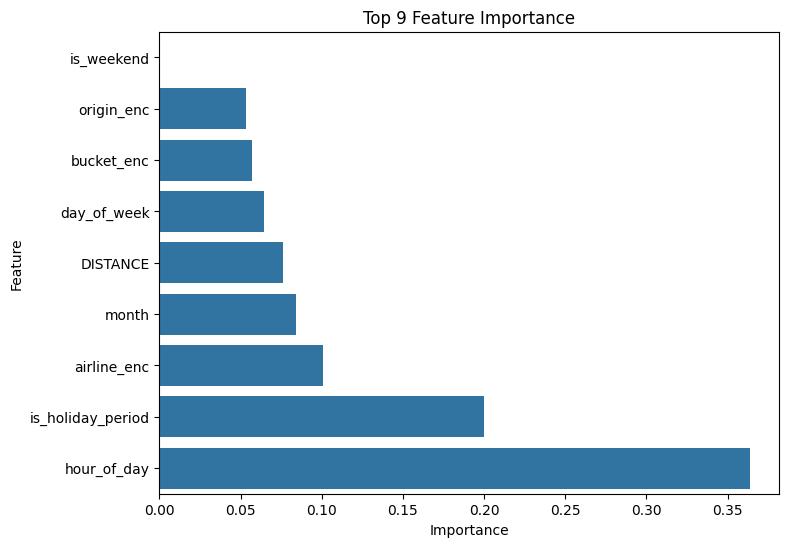

Saved: outputs/charts/feature_importance_time.png


In [7]:
# --- 2.2e: Generate and save evaluation visuals ---
cm_path = plot_confusion_matrix(y_test_t, y_pred_t, "confusion_matrix_time.png")
print("Saved:", cm_path)

pr_path = plot_precision_recall_curve(y_test_t, y_scores_t, "pr_curve_time.png")
print("Saved:", pr_path)

fi_names = list(X_train_t.columns)
fi_values = list(model_time.feature_importances_)
fi_path = plot_feature_importance(fi_names, fi_values, "feature_importance_time.png", top_n=15)
print("Saved:", fi_path)


In [8]:
# --- 2.2f: Persist metrics + predictions to lakeFS and commit ---
import tempfile, os

# Save locally then upload
with tempfile.TemporaryDirectory() as tmpdir:
    # Metrics JSON
    metrics_local = os.path.join(tmpdir, "metrics_time.json")
    save_metrics_json(metrics_time, metrics_local)
    with open(metrics_local, "rb") as f:
        repo = lakefs.Repository(config.repo_name, client=lakefs_client)
        repo.branch(BRANCH_TIME).object("gold/metrics_time.json").upload(
            data=f.read(), mode="wb", content_type="application/json"
        )

    # Predictions parquet
    preds_df = pd.DataFrame({"y_true": y_test_t.values, "y_scores": y_scores_t})
    preds_local = os.path.join(tmpdir, "predictions_time.parquet")
    save_predictions_parquet(preds_df, preds_local)
    write_parquet(
        client=lakefs_client,
        repo_name=config.repo_name,
        branch_name=BRANCH_TIME,
        path="gold/predictions_time.parquet",
        df=preds_df,
    )

ref_time = lakefs_commit(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_TIME,
    message="Train XGBoost on time-based features, save metrics",
    metadata={"phase": "phase-5", "layer": "gold", "experiment": "time"},
)
print("Experiment A committed:", getattr(ref_time, "id", ref_time))
print("Metrics:", metrics_time)


Experiment A committed: None
Metrics: {'accuracy': 0.7699633088725817, 'precision': 0.5636313197863929, 'recall': 0.2762312633832976, 'f1': 0.370757299270073, 'auc_pr': 0.49492849461267296}


## Section 2.3 - Experiment B: Route-Based Features

Engineer route/geography features with frequency encoding for high-cardinality
categoricals and leakage-safe delay-rate features computed from the training split only.


In [9]:
# --- 2.3a: Create experiment branch and engineer route features ---
BRANCH_ROUTE = "experiment-route-features"
create_branch(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_ROUTE,
    source_branch="silver",
)
print(f"Branch '{BRANCH_ROUTE}' ready (from silver)")

# Engineer route features from silver dataset
route_df = engineer_route_features(silver_df)
print("Route features engineered, shape:", route_df.shape)
display(route_df[["ORIGIN", "DEST", "route", "DISTANCE", "distance_bucket"]].head(10))


Branch 'experiment-route-features' ready (from silver)
Route features engineered, shape: (454413, 37)


,ORIGIN,DEST,route,DISTANCE,distance_bucket
0,MSP,SFO,MSP-SFO,1589.0,long
1,DCA,BOS,DCA-BOS,399.0,short
2,IAH,LAX,IAH-LAX,1379.0,medium
3,MSP,EWR,MSP-EWR,1008.0,medium
4,USA,SFB,USA-SFB,457.0,short
5,AUS,IAH,AUS-IAH,140.0,short
6,BOS,LGA,BOS-LGA,184.0,short
7,MDW,SAT,MDW-SAT,1036.0,medium
8,DEN,SLC,DEN-SLC,391.0,short
9,TPA,LGA,TPA-LGA,1010.0,medium


In [10]:
# --- 2.3b: Temporal split FIRST, then compute leakage-safe features from train only ---
TARGET_COL = "is_delayed"
CUTOFF_DATE = "2023-07-01"

# We need to split before computing delay rates and frequency encodings
# to prevent data leakage from test into training statistics.
# Include FL_DATE for the temporal split, then drop it afterward.
route_split_df = route_df[["FL_DATE", "AIRLINE_CODE", "ORIGIN", "DEST", "route",
                           "DISTANCE", "distance_bucket", TARGET_COL]].copy()

# Convert categoricals to string for encoding steps
for col in ["AIRLINE_CODE", "ORIGIN", "DEST"]:
    route_split_df[col] = route_split_df[col].astype(str)

# Temporal split — train on data before cutoff, test on data at/after cutoff
# temporal_train_test_split drops FL_DATE and TARGET_COL from the returned X frames
X_train_raw, X_test_raw, y_train_r, y_test_r = temporal_train_test_split(
    route_split_df, target_col=TARGET_COL, date_col="FL_DATE", cutoff_date=CUTOFF_DATE
)
print(f"Temporal split (cutoff={CUTOFF_DATE}) — Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")
print(f"Train delay rate: {y_train_r.mean():.4f}, Test delay rate: {y_test_r.mean():.4f}")


Temporal split (cutoff=2023-07-01) — Train: (334493, 6), Test: (119920, 6)
Train delay rate: 0.2149, Test delay rate: 0.2453


In [11]:
# --- 2.3c: Compute leakage-safe delay rates from train split only ---
train_with_target = X_train_raw.copy()
train_with_target[TARGET_COL] = y_train_r

origin_rates = compute_delay_rates(train_with_target, group_col="ORIGIN", target_col=TARGET_COL)
airline_rates = compute_delay_rates(train_with_target, group_col="AIRLINE_CODE", target_col=TARGET_COL)
route_rates = compute_delay_rates(train_with_target, group_col="route", target_col=TARGET_COL)

# Global train delay rate as fallback for unseen categories
global_delay_rate = float(y_train_r.mean())
print(f"Global train delay rate (fallback): {global_delay_rate:.4f}")
print(f"Unique origins in rates: {len(origin_rates)}, airlines: {len(airline_rates)}, routes: {len(route_rates)}")

# Apply rates to train and test
X_train_raw["origin_delay_rate"] = apply_delay_rates(X_train_raw, origin_rates, col="ORIGIN", default_rate=global_delay_rate)
X_train_raw["airline_delay_rate"] = apply_delay_rates(X_train_raw, airline_rates, col="AIRLINE_CODE", default_rate=global_delay_rate)
X_train_raw["route_delay_rate"] = apply_delay_rates(X_train_raw, route_rates, col="route", default_rate=global_delay_rate)

X_test_raw["origin_delay_rate"] = apply_delay_rates(X_test_raw, origin_rates, col="ORIGIN", default_rate=global_delay_rate)
X_test_raw["airline_delay_rate"] = apply_delay_rates(X_test_raw, airline_rates, col="AIRLINE_CODE", default_rate=global_delay_rate)
X_test_raw["route_delay_rate"] = apply_delay_rates(X_test_raw, route_rates, col="route", default_rate=global_delay_rate)

print("Delay-rate features applied to train and test.")


Global train delay rate (fallback): 0.2149
Unique origins in rates: 348, airlines: 15, routes: 6088
Delay-rate features applied to train and test.


In [12]:
# --- 2.3d: Frequency-encode high-cardinality categoricals ---
FREQ_ENCODE_COLS = ["AIRLINE_CODE", "ORIGIN", "DEST", "route"]

for col in FREQ_ENCODE_COLS:
    train_enc, test_enc = frequency_encode(X_train_raw[col], X_test_raw[col])
    X_train_raw[f"{col}_freq"] = train_enc
    X_test_raw[f"{col}_freq"] = test_enc

# Encode distance_bucket as ordinal
bucket_map = {"short": 0, "medium": 1, "long": 2, "very_long": 3}
X_train_raw["distance_bucket_enc"] = X_train_raw["distance_bucket"].map(bucket_map).fillna(0).astype(int)
X_test_raw["distance_bucket_enc"] = X_test_raw["distance_bucket"].map(bucket_map).fillna(0).astype(int)

# Final feature columns for Experiment B
ROUTE_FEATURE_COLS = [
    "DISTANCE",
    "distance_bucket_enc",
    "AIRLINE_CODE_freq",
    "ORIGIN_freq",
    "DEST_freq",
    "route_freq",
    "origin_delay_rate",
    "airline_delay_rate",
    "route_delay_rate",
]

X_train_r = X_train_raw[ROUTE_FEATURE_COLS].copy()
X_test_r = X_test_raw[ROUTE_FEATURE_COLS].copy()

print("Feature columns:", ROUTE_FEATURE_COLS)
print(f"Final train: {X_train_r.shape}, test: {X_test_r.shape}")
display(X_train_r.head())


Feature columns: ['DISTANCE', 'distance_bucket_enc', 'AIRLINE_CODE_freq', 'ORIGIN_freq', 'DEST_freq', 'route_freq', 'origin_delay_rate', 'airline_delay_rate', 'route_delay_rate']
Final train: (334493, 9), test: (119920, 9)


,DISTANCE,distance_bucket_enc,AIRLINE_CODE_freq,ORIGIN_freq,DEST_freq,route_freq,origin_delay_rate,airline_delay_rate,route_delay_rate
0,1589.0,2,0.143839,0.017941,0.019752,0.000296,0.170305,0.182820,0.191919
1,399.0,0,0.137922,0.021181,0.021223,0.001576,0.175018,0.240799,0.185958
2,1379.0,1,0.038802,0.016939,0.028524,0.000759,0.256265,0.303259,0.236220
3,1008.0,1,0.045819,0.017941,0.021047,0.000311,0.170305,0.137348,0.163462
4,457.0,0,0.017675,0.000105,0.001309,0.000039,0.285714,0.266746,0.307692


In [13]:
# --- 2.3e: Persist gold feature artifact and commit ---
features_route = pd.concat([X_train_r, X_test_r], axis=0)
features_route[TARGET_COL] = pd.concat([y_train_r, y_test_r], axis=0)

write_parquet(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_ROUTE,
    path="gold/features_route.parquet",
    df=features_route,
)
lakefs_commit(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_ROUTE,
    message="Gold layer: route-based features",
    metadata={"phase": "phase-6", "layer": "gold", "experiment": "route"},
)
print("gold/features_route.parquet committed on", BRANCH_ROUTE)


gold/features_route.parquet committed on experiment-route-features


In [14]:
# --- 2.3f: Train XGBoost model (same hyperparameters as Experiment A) ---
model_route = create_xgboost_classifier(random_state=42)
model_route.fit(X_train_r, y_train_r)
print("XGBoost (route) training complete")

# Predict
y_pred_r = model_route.predict(X_test_r)
y_scores_r = model_route.predict_proba(X_test_r)[:, 1]

# Compute metrics
metrics_route = compute_binary_classification_metrics(y_test_r, y_pred_r, y_scores_r)
print("\n=== Experiment B (Route Features) Metrics ===")
for k, v in metrics_route.items():
    print(f"  {k}: {v:.4f}")


XGBoost (route) training complete

=== Experiment B (Route Features) Metrics ===
  accuracy: 0.7522
  precision: 0.3790
  recall: 0.0157
  f1: 0.0302
  auc_pr: 0.3101


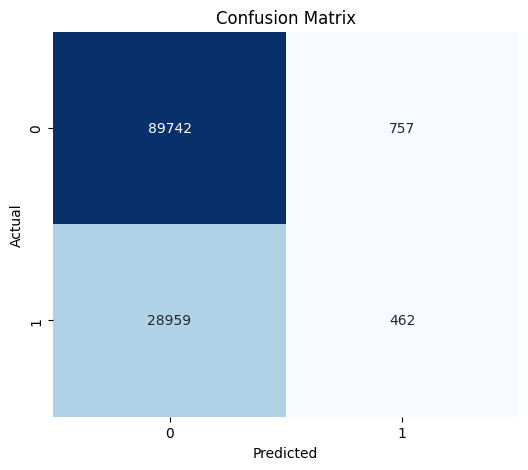

Saved: outputs/charts/confusion_matrix_route.png


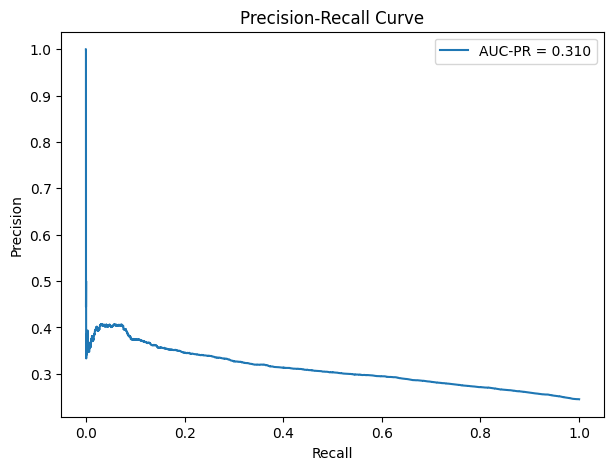

Saved: outputs/charts/pr_curve_route.png


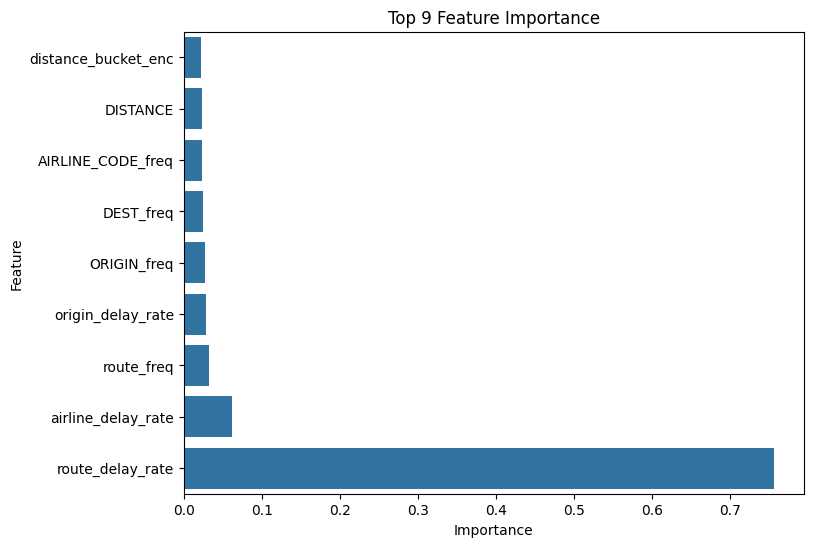

Saved: outputs/charts/feature_importance_route.png


In [15]:
# --- 2.3g: Generate and save evaluation visuals ---
cm_path_r = plot_confusion_matrix(y_test_r, y_pred_r, "confusion_matrix_route.png")
print("Saved:", cm_path_r)

pr_path_r = plot_precision_recall_curve(y_test_r, y_scores_r, "pr_curve_route.png")
print("Saved:", pr_path_r)

fi_names_r = list(X_train_r.columns)
fi_values_r = list(model_route.feature_importances_)
fi_path_r = plot_feature_importance(fi_names_r, fi_values_r, "feature_importance_route.png", top_n=15)
print("Saved:", fi_path_r)


In [16]:
# --- 2.3h: Persist metrics + predictions to lakeFS and commit ---
import tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    # Metrics JSON
    metrics_local_r = os.path.join(tmpdir, "metrics_route.json")
    save_metrics_json(metrics_route, metrics_local_r)
    with open(metrics_local_r, "rb") as f:
        repo = lakefs.Repository(config.repo_name, client=lakefs_client)
        repo.branch(BRANCH_ROUTE).object("gold/metrics_route.json").upload(
            data=f.read(), mode="wb", content_type="application/json"
        )

    # Predictions parquet
    preds_df_r = pd.DataFrame({"y_true": y_test_r.values, "y_scores": y_scores_r})
    preds_local_r = os.path.join(tmpdir, "predictions_route.parquet")
    save_predictions_parquet(preds_df_r, preds_local_r)
    write_parquet(
        client=lakefs_client,
        repo_name=config.repo_name,
        branch_name=BRANCH_ROUTE,
        path="gold/predictions_route.parquet",
        df=preds_df_r,
    )

ref_route = lakefs_commit(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_ROUTE,
    message="Train XGBoost on route-based features, save metrics",
    metadata={"phase": "phase-6", "layer": "gold", "experiment": "route"},
)
print("Experiment B committed:", getattr(ref_route, "id", ref_route))
print("Metrics:", metrics_route)


Experiment B committed: None
Metrics: {'accuracy': 0.7522014676450968, 'precision': 0.37899917965545526, 'recall': 0.015703069236259814, 'f1': 0.030156657963446475, 'auc_pr': 0.31014064048256285}


## Section 2.4 - Comparison, Winner Selection & Merge

Load metrics and predictions from both experiment branches, build a side-by-side
comparison table, generate an overlay PR curve, select the winner (primary: F1,
tiebreaker: AUC-PR), and merge the winning experiment branch into `main`.


In [17]:
# --- 2.4a: Load metrics and predictions from both experiment branches ---
BRANCH_TIME = "experiment-time-features"
BRANCH_ROUTE = "experiment-route-features"

# Load metrics JSON from each experiment branch
metrics_time = load_metrics_from_lakefs(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_TIME,
    path="gold/metrics_time.json",
)
metrics_route = load_metrics_from_lakefs(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_ROUTE,
    path="gold/metrics_route.json",
)

# Load prediction arrays for PR curve overlay
preds_time = load_predictions_from_lakefs(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_TIME,
    path="gold/predictions_time.parquet",
)
preds_route = load_predictions_from_lakefs(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=BRANCH_ROUTE,
    path="gold/predictions_route.parquet",
)

print("Experiment A (Time) metrics:", metrics_time)
print("Experiment B (Route) metrics:", metrics_route)
print(f"Predictions loaded — Time: {preds_time.shape}, Route: {preds_route.shape}")


Experiment A (Time) metrics: {'accuracy': 0.7699633088725817, 'auc_pr': 0.49492849461267296, 'f1': 0.370757299270073, 'precision': 0.5636313197863929, 'recall': 0.2762312633832976}
Experiment B (Route) metrics: {'accuracy': 0.7522014676450968, 'auc_pr': 0.31014064048256285, 'f1': 0.030156657963446475, 'precision': 0.37899917965545526, 'recall': 0.015703069236259814}
Predictions loaded — Time: (119920, 2), Route: (119920, 2)


In [18]:
# --- 2.4b: Build side-by-side comparison table ---
comparison = pd.DataFrame({
    "Metric": list(metrics_time.keys()),
    "Experiment A (Time)": [f"{v:.4f}" for v in metrics_time.values()],
    "Experiment B (Route)": [f"{v:.4f}" for v in metrics_route.values()],
})

# Add a 'Winner' column
winners = []
for metric in metrics_time.keys():
    if metrics_time[metric] > metrics_route[metric]:
        winners.append("A (Time)")
    elif metrics_time[metric] < metrics_route[metric]:
        winners.append("B (Route)")
    else:
        winners.append("Tie")
comparison["Winner"] = winners

print("\n=== Experiment Comparison ===")
display(comparison)



=== Experiment Comparison ===


,Metric,Experiment A (Time),Experiment B (Route),Winner
0,accuracy,0.7700,0.7522,A (Time)
1,auc_pr,0.4949,0.3101,A (Time)
2,f1,0.3708,0.0302,A (Time)
3,precision,0.5636,0.3790,A (Time)
4,recall,0.2762,0.0157,A (Time)


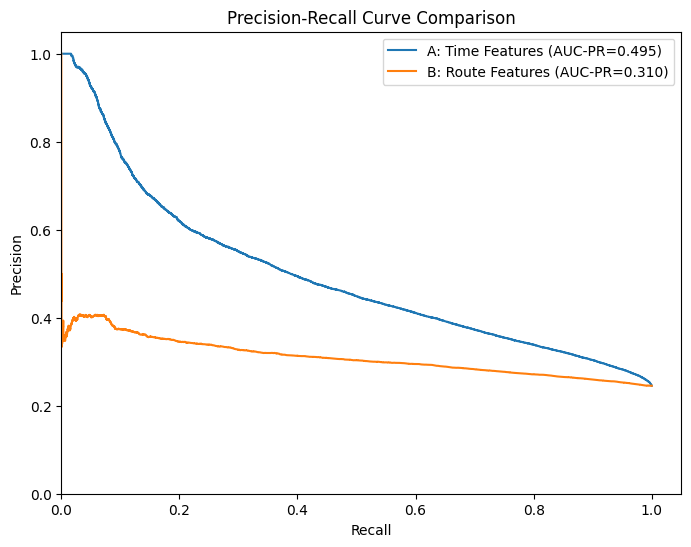

Saved overlay PR curve: outputs/charts/pr_curve_overlay.png


In [19]:
# --- 2.4c: Generate overlay PR curve ---
overlay_path = plot_pr_curve_overlay(
    experiments={
        "A: Time Features": (preds_time["y_true"], preds_time["y_scores"]),
        "B: Route Features": (preds_route["y_true"], preds_route["y_scores"]),
    },
    filename="pr_curve_overlay.png",
)
print("Saved overlay PR curve:", overlay_path)


In [20]:
# --- 2.4d: Apply winner decision rule (primary: F1, tiebreaker: AUC-PR) ---
f1_time = metrics_time["f1"]
f1_route = metrics_route["f1"]
auc_time = metrics_time["auc_pr"]
auc_route = metrics_route["auc_pr"]

print(f"F1 scores  — Time: {f1_time:.4f}, Route: {f1_route:.4f}")
print(f"AUC-PR     — Time: {auc_time:.4f}, Route: {auc_route:.4f}")

if f1_time > f1_route:
    winner_name = "Time Features (Experiment A)"
    winner_branch = BRANCH_TIME
elif f1_route > f1_time:
    winner_name = "Route Features (Experiment B)"
    winner_branch = BRANCH_ROUTE
else:
    # Tiebreaker: AUC-PR
    if auc_time >= auc_route:
        winner_name = "Time Features (Experiment A)"
        winner_branch = BRANCH_TIME
    else:
        winner_name = "Route Features (Experiment B)"
        winner_branch = BRANCH_ROUTE

print(f"\nWinner: {winner_name}")
print(f"Winner branch: {winner_branch}")


F1 scores  — Time: 0.3708, Route: 0.0302
AUC-PR     — Time: 0.4949, Route: 0.3101

Winner: Time Features (Experiment A)
Winner branch: experiment-time-features


In [21]:
# --- 2.4e: Merge winner branch into main ---
merge_message = f"Merge winning experiment ({winner_name}) to main"
print(f"Merging '{winner_branch}' -> 'main'")
print(f"Message: {merge_message}")

merge_ref = merge_branch(
    client=lakefs_client,
    repo_name=config.repo_name,
    source_branch=winner_branch,
    dest_branch="main",
    message=merge_message,
)
print(f"Merge complete: {merge_ref}")


Merging 'experiment-time-features' -> 'main'
Message: Merge winning experiment (Time Features (Experiment A)) to main
Merge complete: None


In [22]:
# --- 2.4f: Print final commit lineage ---
print("=" * 60)
print("lakeFS Commit Lineage: flight-delay-demo")
print("=" * 60)

# Show main branch log to demonstrate full lineage
main_log = get_branch_log(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name="main",
    max_entries=15,
)

for entry in main_log:
    commit_id = entry['id'][:8]
    message = entry['message']
    meta = entry.get('metadata', {})
    phase = meta.get('phase', '')
    layer = meta.get('layer', '')
    tag = f" [{phase}/{layer}]" if phase else ""
    print(f"  {commit_id}  {message}{tag}")

print("\n" + "=" * 60)
print("Lineage summary:")
print("  bronze (main) -> silver -> experiment branches -> merge winner to main")
print(f"  Winner: {winner_name}")
print("=" * 60)


lakeFS Commit Lineage: flight-delay-demo
  89c1b6e8  Merge winning experiment (Time Features (Experiment A)) to main
  8fa5f71c  Train XGBoost on time-based features, save metrics [phase-5/gold]
  5ffca4e2  Train XGBoost on time-based features, save metrics [phase-5/gold]
  30aaf293  Test commit [phase-5/gold]
  fb8c019a  Merge winning experiment (Time Features (Experiment A)) to main
  4bc1c7e4  Train XGBoost on time-based features, save metrics [phase-5/gold]
  6a93a745  Gold layer: time-based features [phase-5/gold]
  54d9600d  Clean flight data, create delay target (silver layer) [phase-3/silver]
  ce974476  Ingest raw 2023 flight data (bronze layer) [phase-2/bronze]
  ac1f7b57  Repository created

Lineage summary:
  bronze (main) -> silver -> experiment branches -> merge winner to main
  Winner: Time Features (Experiment A)
